import the data

In [12]:
import os
from torchvision import transforms
from PIL import Image
from pathlib import Path
import random
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms
import random

In [13]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Dataset'
healthy_path = os.path.join(dataset_path, 'Healthy')
autism_path = os.path.join(dataset_path, 'Autistic')
ndd_path = os.path.join(dataset_path, 'NDD')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
label_mapping = {
    'Healthy': 0,
    'Autistic': 1,
    'NDD': 2
}

data = []

for label_name, label in label_mapping.items():
    folder_path = os.path.join(dataset_path, label_name)
    for image_file in os.listdir(folder_path):
      data.append((os.path.join(folder_path, image_file), label))


from collections import Counter

labels = [label for _, label in data]

class_counts = Counter(labels)

print(f"Total images: {len(data)}")
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count} images")


Total images: 4410
Class 0: 1470 images
Class 1: 1470 images
Class 2: 1470 images


augmentation

In [15]:
pip install tqdm

In [16]:
from collections import defaultdict
from tqdm import tqdm
import torch


random.seed(42)

augmentation_transforms = transforms.Compose([
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

augmented_data = []
class_counts = defaultdict(int)  # Dictionary to count images per class

# Wrap the data in tqdm for the progress bar
for image_path, label in tqdm(data, desc="Processing images", unit="image"):
    image = Image.open(image_path)
    image_tensor = augmentation_transforms(image)

    augmented_data.append((image_tensor, label))  # Original image
    augmented_data.append((image_tensor, label))  # Augmented image

    class_counts[label] += 2

#torch.save(augmented_data, "augmented_dataset.pt")
save_path = "/content/drive/MyDrive/augmented_dataset2.pt"
torch.save(augmented_data, save_path)

print("Dataset saved successfully to 'augmented_dataset2.pt'")

total_images = len(augmented_data)
print(f"Total images: {total_images}")
for label, count in class_counts.items():
    print(f"Class {label}: {count} images")


Processing images: 100%|██████████| 4410/4410 [28:27<00:00,  2.58image/s]


Dataset saved successfully to 'augmented_dataset2.pt'
Total images: 8820
Class 0: 2940 images
Class 1: 2940 images
Class 2: 2940 images


In [17]:
#augmented_data = torch.load("augmented_dataset.pt")
augmented_data = torch.load("/content/drive/MyDrive/augmented_dataset2.pt")

print(f"Loaded dataset size: {len(augmented_data)}")


<ipython-input-17-0e6648a76983>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  augmented_data = torch.load("/content/drive/MyDrive/augmented_dataset2.pt")


Loaded dataset size: 8820


70 train

In [26]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(augmented_data, test_size=0.30, stratify=[label for _, label in augmented_data])

# Split the temp data into test (15%) and validation (15%)
test_data, val_data = train_test_split(temp_data, test_size=0.50, stratify=[label for _, label in temp_data])

print(f"After augmentation - Total images: {len(augmented_data)}")
print(f"Training data: {len(train_data)} samples")
print(f"Validation data: {len(val_data)} samples")
print(f"Test data: {len(test_data)} samples")


After augmentation - Total images: 8820
Training data: 6174 samples
Validation data: 1323 samples
Test data: 1323 samples


80 train

In [ ]:
from sklearn.model_selection import train_test_split
train_data, temp_data = train_test_split(augmented_data, test_size=0.20, stratify=[label for _, label in augmented_data])

# Split the temp data into test (10%) and validation (10%)
test_data, val_data = train_test_split(temp_data, test_size=0.50, stratify=[label for _, label in temp_data])

print(f"After augmentation - Total images: {len(augmented_data)}")
print(f"Training data: {len(train_data)} samples")
print(f"Validation data: {len(val_data)} samples")
print(f"Test data: {len(test_data)} samples")


After augmentation - Total images: 8820
Training data: 7056 samples
Validation data: 882 samples
Test data: 882 samples


In [27]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# Create TensorDataset
train_data = TensorDataset(torch.stack([item[0] for item in train_data]), torch.tensor([item[1] for item in train_data]))
val_data = TensorDataset(torch.stack([item[0] for item in val_data]), torch.tensor([item[1] for item in val_data]))
test_data = TensorDataset(torch.stack([item[0] for item in test_data]), torch.tensor([item[1] for item in test_data]))


# Create DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

tiny

In [28]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import convnext_tiny

# Load the pre-trained ConvNeXt tiny model
model = convnext_tiny(pretrained=True)

num_classes = len(label_mapping)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 220MB/s]


base

In [22]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import convnext_base

# Load the pre-trained ConvNeXt Base model
model = convnext_base(pretrained=True)

num_classes = len(label_mapping)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

large

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import convnext_large


# Load the pre-trained ConvNeXt Large model
model = convnext_large(pretrained=True)

num_classes = len(label_mapping)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)



train

In [29]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step()

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)


Epoch 1/10
Train Loss: 0.3305, Train Accuracy: 0.8602
Val Loss: 0.1489, Val Accuracy: 0.9456
Epoch 2/10
Train Loss: 0.0919, Train Accuracy: 0.9663
Val Loss: 0.0920, Val Accuracy: 0.9660
Epoch 3/10
Train Loss: 0.0395, Train Accuracy: 0.9872
Val Loss: 0.1475, Val Accuracy: 0.9471
Epoch 4/10
Train Loss: 0.0214, Train Accuracy: 0.9938
Val Loss: 0.0854, Val Accuracy: 0.9735
Epoch 5/10
Train Loss: 0.0190, Train Accuracy: 0.9942
Val Loss: 0.0670, Val Accuracy: 0.9811
Epoch 6/10
Train Loss: 0.0176, Train Accuracy: 0.9947
Val Loss: 0.0975, Val Accuracy: 0.9743
Epoch 7/10
Train Loss: 0.0225, Train Accuracy: 0.9927
Val Loss: 0.1118, Val Accuracy: 0.9751
Epoch 8/10
Train Loss: 0.0046, Train Accuracy: 0.9987
Val Loss: 0.0803, Val Accuracy: 0.9811
Epoch 9/10
Train Loss: 0.0026, Train Accuracy: 0.9994
Val Loss: 0.0815, Val Accuracy: 0.9811
Epoch 10/10
Train Loss: 0.0026, Train Accuracy: 0.9990
Val Loss: 0.0819, Val Accuracy: 0.9856


In [24]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {correct / total:.4f}")

test_model(model, test_loader)


Test Accuracy: 0.9826


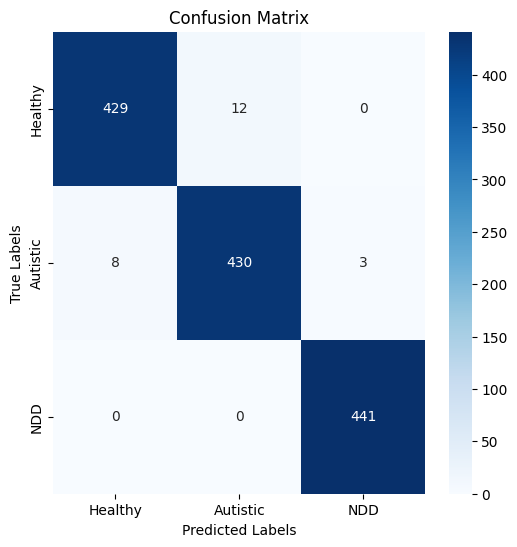

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.98       441
    Autistic       0.97      0.98      0.97       441
         NDD       0.99      1.00      1.00       441

    accuracy                           0.98      1323
   macro avg       0.98      0.98      0.98      1323
weighted avg       0.98      0.98      0.98      1323



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


true_labels = []
predicted_labels = []

# Evaluate on the test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_mapping.keys()), yticklabels=list(label_mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report (Accuracy, Precision, Recall, F1-score)
report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.keys()))
print("Classification Report:")
print(report)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models import convnext_base
from PIL import Image
import numpy as np

# predict the top 3 classes
def predict_top_classes(model, image_path, label_mapping, top_k=3):
    image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_image = preprocess(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_image)

    # Get the top k classes
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    top_probs, top_classes = torch.topk(probabilities, top_k)

    top_probs = top_probs.squeeze().cpu().numpy()
    top_classes = top_classes.squeeze().cpu().numpy()

    class_names = [list(label_mapping.keys())[i] for i in top_classes]

    print(f"Top {top_k} predictions:")
    for i in range(top_k):
        print(f"{class_names[i]}: {top_probs[i] * 100:.2f}%")

image_path = '/content/drive/MyDrive/2.jpg'
predict_top_classes(model, image_path, label_mapping)


Top 3 predictions:
NDD: 100.00%
Autistic: 0.00%
Healthy: 0.00%


grad cam